In [25]:
# We will work with patient 0676 for this example
# files
# icare_data\training\0676\0676.txt
# icare_data\training\0676\0676_001_012_EEG.hea
# icare_data\training\0676\0676_001_012_EEG.mat
# icare_data\training\0676\0676_002_013_EEG.hea
# icare_data\training\0676\0676_002_013_EEG.mat

In [29]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import scipy.io


CANONICAL_19_ORDER: tuple[str, ...] = (
    "Fp1",
    "Fp2",
    "F3",
    "F4",
    "C3",
    "C4",
    "P3",
    "P4",
    "O1",
    "O2",
    "F7",
    "F8",
    "T3",
    "T4",
    "T5",
    "T6",
    "Fz",
    "Cz",
    "Pz",
)

CHANNEL_ALIASES: dict[str, str] = {
    "T7": "T3",
    "T8": "T4",
    "P7": "T5",
    "P8": "T6",
}

BIPOLAR_18_PAIRS: tuple[tuple[str, str], ...] = (
    ("Fp1", "F7"),
    ("F7", "T3"),
    ("T3", "T5"),
    ("T5", "O1"),
    ("Fp2", "F8"),
    ("F8", "T4"),
    ("T4", "T6"),
    ("T6", "O2"),
    ("Fp1", "F3"),
    ("F3", "C3"),
    ("C3", "P3"),
    ("P3", "O1"),
    ("Fp2", "F4"),
    ("F4", "C4"),
    ("C4", "P4"),
    ("P4", "O2"),
    ("Fz", "Cz"),
    ("Cz", "Pz"),
)


@dataclass(frozen=True)
class SegmentRecord:
    """Represents one paired WFDB segment (.hea + .mat)."""

    patient_id: str
    segment_id: str
    hour_token: str
    signal_type: str
    hea_path: Path
    mat_path: Path


def normalize_channel_label(channel_name: str) -> str:
    """Normalize EEG channel names into canonical 10-20 labels.

    Args:
        channel_name: Raw channel label from WFDB header.

    Returns:
        Canonicalized channel label.
    """
    compact_name = channel_name.strip().replace(" ", "")
    normalized = compact_name.upper()

    alias_candidates = {
        "FP1": "Fp1",
        "FP2": "Fp2",
        "F3": "F3",
        "F4": "F4",
        "C3": "C3",
        "C4": "C4",
        "P3": "P3",
        "P4": "P4",
        "O1": "O1",
        "O2": "O2",
        "F7": "F7",
        "F8": "F8",
        "T3": "T3",
        "T4": "T4",
        "T5": "T5",
        "T6": "T6",
        "T7": "T3",
        "T8": "T4",
        "P7": "T5",
        "P8": "T6",
        "FZ": "Fz",
        "CZ": "Cz",
        "PZ": "Pz",
    }

    if normalized in alias_candidates:
        return alias_candidates[normalized]

    return compact_name


def parse_hea_header(hea_path: Path) -> dict[str, object]:
    """Parse channel metadata and timing details from a WFDB .hea file.

    Args:
        hea_path: Path to the WFDB header file.

    Returns:
        Parsed metadata including channel names, gains, baselines, sampling rate,
        and total sample count.

    Raises:
        FileNotFoundError: If the header file is missing.
        ValueError: If the header content is invalid.
    """
    if not hea_path.exists():
        raise FileNotFoundError(f"Header not found: {hea_path}")

    lines = hea_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    if not lines:
        raise ValueError(f"Empty header file: {hea_path}")

    first_tokens = lines[0].split()
    if len(first_tokens) < 4:
        raise ValueError(f"Invalid first header line in {hea_path}")

    sampling_rate_hz = float(first_tokens[2])
    total_samples = int(first_tokens[3])

    raw_channel_names: list[str] = []
    channel_names: list[str] = []
    gains: list[float] = []
    baselines: list[int] = []

    for line in lines[1:]:
        if not line.strip() or line.startswith("#"):
            break
        parts = line.split()
        if len(parts) < 3:
            continue

        gain_baseline_match = re.match(r"([\d\.eE+\-]+)\(([+\-]?\d+)\)", parts[2])
        if gain_baseline_match:
            gains.append(float(gain_baseline_match.group(1)))
            baselines.append(int(gain_baseline_match.group(2)))
        else:
            gains.append(1.0)
            baselines.append(0)

        raw_channel_name = parts[-1]
        raw_channel_names.append(raw_channel_name)
        channel_names.append(normalize_channel_label(raw_channel_name))

    if not channel_names:
        raise ValueError(f"No channels parsed from header: {hea_path}")

    duplicate_names = sorted(
        {name for name in channel_names if channel_names.count(name) > 1}
    )

    gains_array = np.array(gains, dtype=float)
    gains_array[gains_array == 0.0] = 1.0

    return {
        "sampling_rate_hz": sampling_rate_hz,
        "total_samples": total_samples,
        "channel_names": channel_names,
        "raw_channel_names": raw_channel_names,
        "gains": gains_array,
        "baselines": np.array(baselines, dtype=float),
        "duplicate_channel_names": duplicate_names,
    }


def load_icare_segment(
    hea_path: Path, mat_path: Path
) -> tuple[np.ndarray, dict[str, object]]:
    """Load one I-CARE segment and convert raw ADC values to microvolts.

    Args:
        hea_path: Path to segment header file.
        mat_path: Path to segment MAT signal file.

    Returns:
        Tuple of calibrated signal matrix (channels x samples) and metadata.

    Raises:
        FileNotFoundError: If either file is missing.
        ValueError: If data shape cannot be aligned to header channels.
    """
    if not mat_path.exists():
        raise FileNotFoundError(f"Signal file not found: {mat_path}")

    metadata = parse_hea_header(hea_path)
    channel_names = metadata["channel_names"]
    gains = metadata["gains"]
    baselines = metadata["baselines"]

    mat_data = scipy.io.loadmat(str(mat_path), squeeze_me=True, struct_as_record=False)
    candidate_arrays = {
        key: value
        for key, value in mat_data.items()
        if isinstance(value, np.ndarray) and value.ndim == 2 and value.size > 1
    }

    if not candidate_arrays:
        raise ValueError(f"No 2D signal matrix found in MAT file: {mat_path}")

    raw_key = max(candidate_arrays, key=lambda key: candidate_arrays[key].size)
    raw_signal = candidate_arrays[raw_key].astype(float)

    n_channels = len(channel_names)
    if raw_signal.shape[0] == n_channels:
        aligned_signal = raw_signal
    elif raw_signal.shape[1] == n_channels:
        aligned_signal = raw_signal.T
    else:
        raise ValueError(
            "Channel count mismatch between header and MAT data: "
            f"header={n_channels}, mat_shape={raw_signal.shape}"
        )

    calibrated_signal_uv = (aligned_signal - baselines[:, None]) / gains[:, None]
    metadata["mat_key"] = raw_key
    metadata["raw_shape"] = raw_signal.shape
    metadata["calibrated_shape"] = calibrated_signal_uv.shape

    return calibrated_signal_uv, metadata


def discover_icare_segments(root_dir: Path) -> list[SegmentRecord]:
    """Find valid WFDB segment pairs under the training directory.

    Args:
        root_dir: Root directory that contains patient subfolders.

    Returns:
        Sorted list of segment records that have both .hea and .mat files.
    """
    records: list[SegmentRecord] = []
    pattern = re.compile(
        r"^(?P<patient>\d{4})_(?P<segment>\d{3})_(?P<hour>\d{3})_(?P<signal>[A-Z0-9]+)$"
    )

    for hea_path in sorted(root_dir.glob("*/*.hea")):
        stem_match = pattern.match(hea_path.stem)
        if stem_match is None:
            continue

        mat_path = hea_path.with_suffix(".mat")
        if not mat_path.exists():
            continue

        records.append(
            SegmentRecord(
                patient_id=stem_match.group("patient"),
                segment_id=stem_match.group("segment"),
                hour_token=stem_match.group("hour"),
                signal_type=stem_match.group("signal"),
                hea_path=hea_path,
                mat_path=mat_path,
            )
        )

    records.sort(
        key=lambda record: (
            record.signal_type,
            record.patient_id,
            record.segment_id,
            record.hour_token,
        )
    )
    return records


def select_static_examples(
    records: list[SegmentRecord],
    signal_types: tuple[str, ...],
    max_examples_per_type: int,
    preferred_patients: Optional[set[str]] = None,
    preferred_segment_id: Optional[str] = None,
) -> list[SegmentRecord]:
    """Select deterministic examples per signal type for static visualization."""
    selected: list[SegmentRecord] = []
    preferred_patients = preferred_patients or set()

    for signal_type in signal_types:
        by_type = [record for record in records if record.signal_type == signal_type]
        if preferred_segment_id:
            by_type = [
                record
                for record in by_type
                if record.segment_id == preferred_segment_id
            ]

        if preferred_patients:
            prioritized = [
                record for record in by_type if record.patient_id in preferred_patients
            ]
            fallback = [
                record
                for record in by_type
                if record.patient_id not in preferred_patients
            ]
            by_type = prioritized + fallback

        selected.extend(by_type[:max_examples_per_type])

    return selected


def standardize_to_19_channels(
    signal_uv: np.ndarray, channel_names: list[str]
) -> tuple[np.ndarray, dict[str, object]]:
    """Reorder/calibrate monopolar EEG to canonical 19-channel order.

    Args:
        signal_uv: Signal matrix with shape (channels, samples).
        channel_names: Channel names aligned with signal rows.

    Returns:
        Tuple of reordered matrix (19, samples) with NaNs for missing channels,
        and diagnostics describing missing/unknown/duplicate labels.
    """
    canonical_index = {name: idx for idx, name in enumerate(CANONICAL_19_ORDER)}
    normalized_names = [normalize_channel_label(name) for name in channel_names]

    standardized = np.full(
        (len(CANONICAL_19_ORDER), signal_uv.shape[1]), np.nan, dtype=float
    )
    unknown_channels: list[str] = []
    duplicate_canonical: list[str] = []

    seen: set[str] = set()
    for source_idx, channel_name in enumerate(normalized_names):
        if channel_name not in canonical_index:
            unknown_channels.append(channel_name)
            continue

        target_idx = canonical_index[channel_name]
        if channel_name in seen:
            duplicate_canonical.append(channel_name)
            continue

        standardized[target_idx, :] = signal_uv[source_idx, :]
        seen.add(channel_name)

    missing_channels = [
        channel_name
        for channel_name in CANONICAL_19_ORDER
        if channel_name not in seen
    ]

    diagnostics = {
        "input_channel_names": channel_names,
        "normalized_channel_names": normalized_names,
        "canonical_order": list(CANONICAL_19_ORDER),
        "missing_canonical_channels": missing_channels,
        "unknown_channels": sorted(set(unknown_channels)),
        "duplicate_canonical_channels": sorted(set(duplicate_canonical)),
    }
    return standardized, diagnostics


def to_bipolar_18(
    standardized_monopolar_uv: np.ndarray,
) -> tuple[np.ndarray, list[str], np.ndarray, list[str]]:
    """Convert canonical 19-channel monopolar EEG into fixed 18 bipolar pairs.

    Args:
        standardized_monopolar_uv: Matrix in canonical 19 order.

    Returns:
        Bipolar matrix (18, samples), bipolar names, missing-pair mask, missing-pair names.
    """
    canonical_index = {name: idx for idx, name in enumerate(CANONICAL_19_ORDER)}
    bipolar_names = [f"{left}-{right}" for left, right in BIPOLAR_18_PAIRS]

    n_pairs = len(BIPOLAR_18_PAIRS)
    n_samples = standardized_monopolar_uv.shape[1]
    bipolar_uv = np.full((n_pairs, n_samples), np.nan, dtype=float)
    missing_mask = np.zeros(n_pairs, dtype=bool)
    missing_pair_names: list[str] = []

    for pair_idx, (left_channel, right_channel) in enumerate(BIPOLAR_18_PAIRS):
        left_signal = standardized_monopolar_uv[canonical_index[left_channel], :]
        right_signal = standardized_monopolar_uv[canonical_index[right_channel], :]

        if np.isnan(left_signal).all() or np.isnan(right_signal).all():
            missing_mask[pair_idx] = True
            missing_pair_names.append(f"{left_channel}-{right_channel}")
            continue

        bipolar_uv[pair_idx, :] = left_signal - right_signal

    return bipolar_uv, bipolar_names, missing_mask, missing_pair_names


def prepare_bipolar_segment(
    signal_uv: np.ndarray, metadata: dict[str, object]
) -> tuple[np.ndarray, dict[str, object]]:
    """Prepare one segment for bipolar analysis with readiness diagnostics.

    Args:
        signal_uv: Raw calibrated matrix from loader.
        metadata: Loader metadata containing channel names.

    Returns:
        Bipolar signal matrix and updated metadata containing preprocessing diagnostics.
    """
    standardized, diagnostics = standardize_to_19_channels(
        signal_uv=signal_uv, channel_names=list(metadata["channel_names"])
    )
    bipolar_uv, bipolar_names, missing_pair_mask, missing_pairs = to_bipolar_18(
        standardized_monopolar_uv=standardized
    )

    metadata = dict(metadata)
    metadata["preprocess_mode"] = "bipolar"
    metadata["standardized_monopolar_shape"] = standardized.shape
    metadata["bipolar_shape"] = bipolar_uv.shape
    metadata["channel_names"] = bipolar_names
    metadata["bipolar_pair_names"] = bipolar_names
    metadata["missing_bipolar_pair_mask"] = missing_pair_mask
    metadata["missing_bipolar_pairs"] = missing_pairs
    metadata["channel_diagnostics"] = diagnostics

    return bipolar_uv, metadata


def summarize_segment(record: SegmentRecord, metadata: dict[str, object]) -> None:
    """Print compact segment metadata for quick exploratory review."""
    total_samples = int(metadata["total_samples"])
    sampling_rate_hz = float(metadata["sampling_rate_hz"])
    duration_s = total_samples / sampling_rate_hz if sampling_rate_hz > 0 else np.nan
    n_channels = len(metadata["channel_names"])

    print(
        " | ".join(
            [
                f"segment={record.patient_id}_{record.segment_id}_{record.hour_token}_{record.signal_type}",
                f"fs={sampling_rate_hz:.2f}Hz",
                f"samples={total_samples}",
                f"duration={duration_s:.1f}s",
                f"channels={n_channels}",
            ]
        )
    )

    if metadata.get("preprocess_mode") == "bipolar":
        missing_pairs = metadata.get("missing_bipolar_pairs", [])
        diagnostics = metadata.get("channel_diagnostics", {})
        missing_canonical = diagnostics.get("missing_canonical_channels", [])
        unknown_channels = diagnostics.get("unknown_channels", [])
        duplicate_channels = diagnostics.get("duplicate_canonical_channels", [])

        print(
            "readiness="
            + ("READY" if not missing_pairs else "PARTIAL")
            + f" | missing_pairs={len(missing_pairs)}"
        )
        if missing_canonical:
            print("  missing_canonical_channels=" + ", ".join(missing_canonical))
        if unknown_channels:
            print("  unknown_channels=" + ", ".join(unknown_channels))
        if duplicate_channels:
            print("  duplicate_canonical_channels=" + ", ".join(duplicate_channels))


def plot_stacked_channels(
    signal_uv: np.ndarray,
    metadata: dict[str, object],
    title: str,
    start_s: float = 0.0,
    duration_s: float = 60.0,
    spacing_uv: Optional[float] = None,
    channel_subset: Optional[list[str]] = None,
    clip_quantile: float = 0.995,
    max_points: int = 15000,
) -> None:
    """Render stacked traces for a selected time window.

    Args:
        signal_uv: Signal matrix with shape (channels, samples).
        metadata: Parsed metadata returned by the loader.
        title: Plot title string.
        start_s: Starting second for plotting window.
        duration_s: Duration of plotting window in seconds.
        spacing_uv: Vertical offset between channels. If None, inferred robustly.
        channel_subset: Optional list of channel names to plot.
        clip_quantile: Symmetric clipping quantile for robust display.
        max_points: Max plotted time points after decimation for readability.
    """
    sampling_rate_hz = float(metadata["sampling_rate_hz"])
    channel_names = list(metadata["channel_names"])

    if channel_subset:
        channel_index_map = {name: idx for idx, name in enumerate(channel_names)}
        selected_indices = [
            channel_index_map[name]
            for name in channel_subset
            if name in channel_index_map
        ]
        if selected_indices:
            signal_uv = signal_uv[selected_indices, :]
            channel_names = [channel_names[idx] for idx in selected_indices]

    start_idx = max(0, int(start_s * sampling_rate_hz))
    end_idx = min(signal_uv.shape[1], int((start_s + duration_s) * sampling_rate_hz))
    if end_idx <= start_idx:
        raise ValueError("Selected plotting window does not contain samples.")

    segment = signal_uv[:, start_idx:end_idx].copy()
    segment -= np.nanmedian(segment, axis=1, keepdims=True)

    step = max(1, int(np.ceil(segment.shape[1] / max_points)))
    segment = segment[:, ::step]
    time_axis = np.arange(start_idx, end_idx, step) / sampling_rate_hz

    clipped = segment.copy()
    if 0.5 < clip_quantile < 1.0:
        abs_limits = np.nanquantile(np.abs(clipped), clip_quantile, axis=1)
        abs_limits[~np.isfinite(abs_limits)] = 1.0
        abs_limits[abs_limits == 0.0] = 1.0
        clipped = np.clip(clipped, -abs_limits[:, None], abs_limits[:, None])

    if spacing_uv is None:
        robust_amp = np.nanquantile(np.abs(clipped), 0.95)
        if not np.isfinite(robust_amp) or robust_amp == 0.0:
            robust_amp = 20.0
        spacing_uv = max(20.0, 2.5 * float(robust_amp))

    n_channels = clipped.shape[0]
    figure, axis = plt.subplots(figsize=(16, max(3.0, n_channels * 0.55 + 1.0)))
    for channel_idx, channel_name in enumerate(channel_names):
        offset = (n_channels - 1 - channel_idx) * spacing_uv
        axis.plot(
            time_axis, clipped[channel_idx] + offset, color="black", linewidth=0.6
        )

    y_ticks = [(n_channels - 1 - idx) * spacing_uv for idx in range(n_channels)]
    axis.set_yticks(y_ticks)
    axis.set_yticklabels(channel_names, fontsize=8)
    axis.set_xlabel("Time (s)")
    axis.set_title(title)
    axis.set_xlim(time_axis[0], time_axis[-1])
    axis.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)

    for spine in ("top", "right"):
        axis.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

In [30]:
# Static exploration settings
DATA_ROOT = Path("icare_data/training")
INCLUDED_SIGNAL_TYPES = ("EEG",)
MAX_EXAMPLES_PER_TYPE = 2
PREFERRED_PATIENTS: set[str] = {"0676"}  # Example: {"0655", "0656"}
PREFERRED_SEGMENT_ID: Optional[str] = None  # Example: "002"

PREPROCESS_MODE = "bipolar"  # Options: "monopolar", "bipolar"

DEFAULT_START_S = 0.0
DEFAULT_DURATION_S = 60.0
DEFAULT_SPACING_UV = 150.0
PLOT_HISTOGRAM = False

all_records = discover_icare_segments(DATA_ROOT)
print(f"Discovered paired segments: {len(all_records)}")

for signal_type in INCLUDED_SIGNAL_TYPES:
    count = sum(record.signal_type == signal_type for record in all_records)
    print(f"  {signal_type}: {count}")

selected_examples = select_static_examples(
    records=all_records,
    signal_types=INCLUDED_SIGNAL_TYPES,
    max_examples_per_type=MAX_EXAMPLES_PER_TYPE,
    preferred_patients=PREFERRED_PATIENTS,
    preferred_segment_id=PREFERRED_SEGMENT_ID,
)

print(f"\nSelected static examples: {len(selected_examples)}")
for record in selected_examples:
    print(
        f"  {record.patient_id}_{record.segment_id}_{record.hour_token}_{record.signal_type}"
    )
print(f"\nPreprocessing mode: {PREPROCESS_MODE}")

Discovered paired segments: 176
  EEG: 76

Selected static examples: 2
  0676_001_012_EEG
  0676_002_013_EEG

Preprocessing mode: bipolar



Loading 0676_001_012_EEG.hea
segment=0676_001_012_EEG | fs=500.00Hz | samples=1225500 | duration=2451.0s | channels=18
readiness=READY | missing_pairs=0


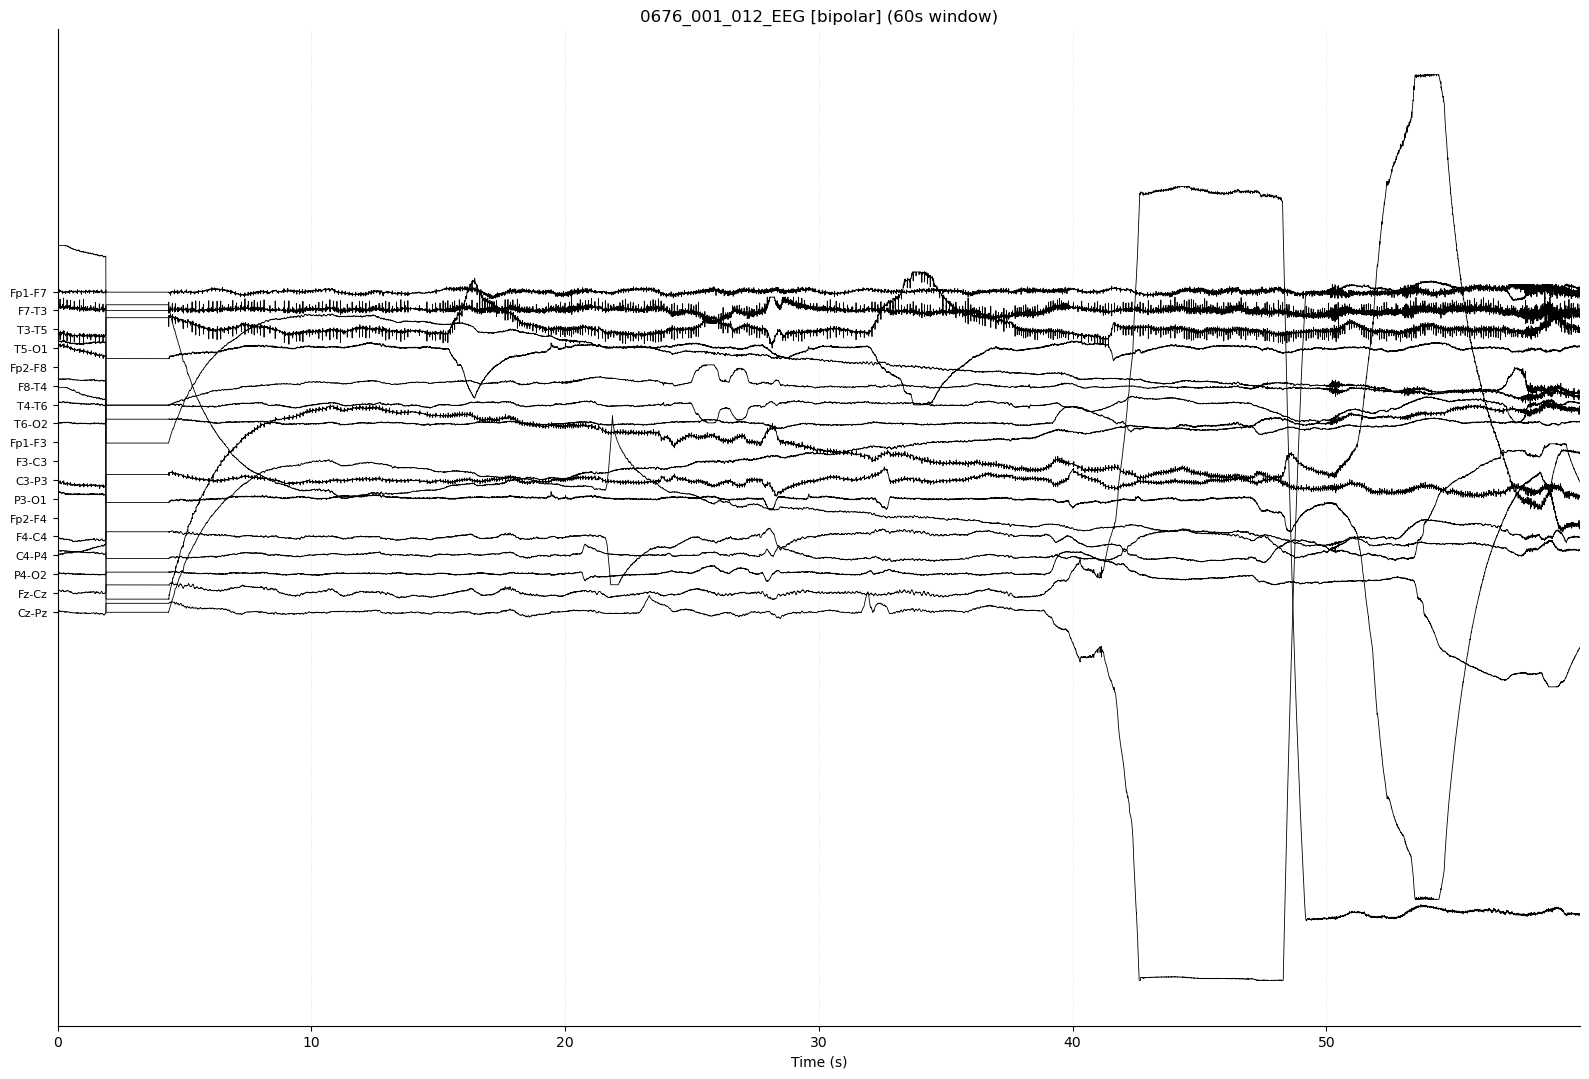


Loading 0676_002_013_EEG.hea
segment=0676_002_013_EEG | fs=500.00Hz | samples=1800000 | duration=3600.0s | channels=18
readiness=READY | missing_pairs=0


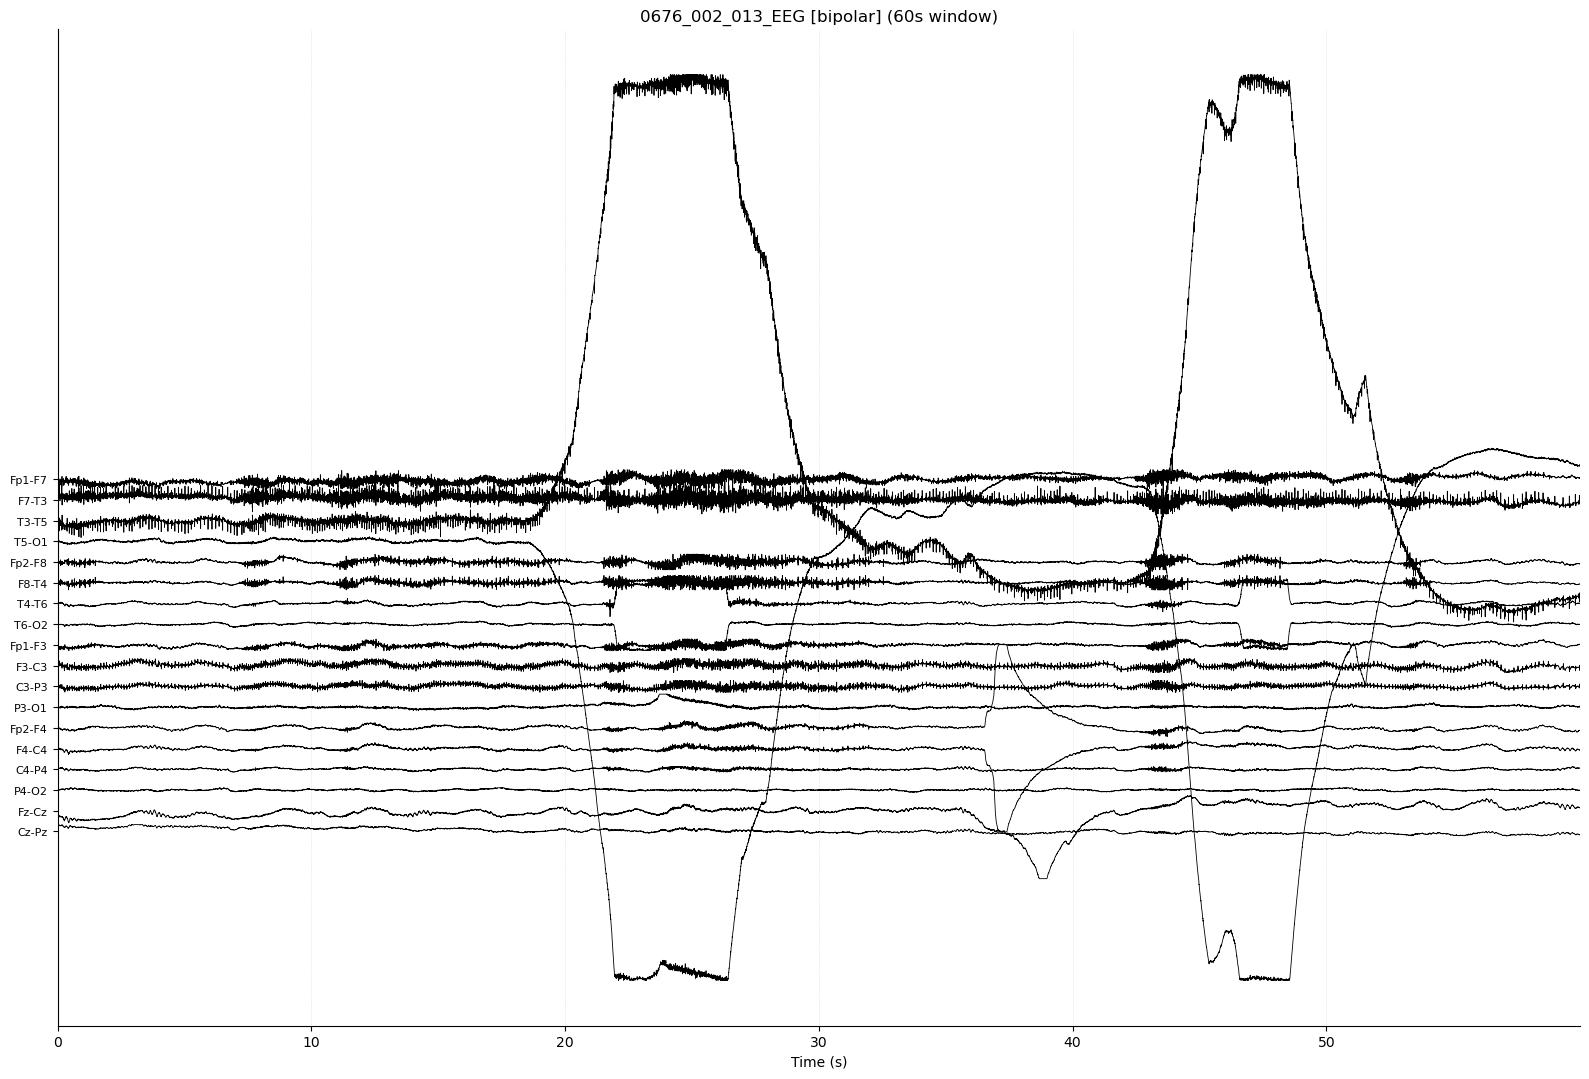

In [31]:
if not selected_examples:
    print("No examples selected. Adjust filters in the previous cell.")

for record in selected_examples:
    print("\n" + "=" * 100)
    print(f"Loading {record.hea_path.name}")

    try:
        signal_uv, metadata = load_icare_segment(record.hea_path, record.mat_path)

        if PREPROCESS_MODE == "bipolar":
            signal_uv, metadata = prepare_bipolar_segment(signal_uv, metadata)
        elif PREPROCESS_MODE != "monopolar":
            raise ValueError(
                f"Unsupported PREPROCESS_MODE={PREPROCESS_MODE}. Use 'monopolar' or 'bipolar'."
            )

        summarize_segment(record, metadata)

        plot_stacked_channels(
            signal_uv=signal_uv,
            metadata=metadata,
            title=(
                f"{record.patient_id}_{record.segment_id}_{record.hour_token}_{record.signal_type} "
                f"[{PREPROCESS_MODE}] ({DEFAULT_DURATION_S:.0f}s window)"
            ),
            start_s=DEFAULT_START_S,
            duration_s=DEFAULT_DURATION_S,
            spacing_uv=DEFAULT_SPACING_UV,
        )

        if PLOT_HISTOGRAM:
            first_channel_name = metadata["channel_names"][0]
            first_channel_data = signal_uv[0]
            finite_values = first_channel_data[np.isfinite(first_channel_data)]
            if finite_values.size == 0:
                print(
                    f"Histogram skipped for {first_channel_name} because values are all NaN."
                )
            else:
                fig, ax = plt.subplots(figsize=(8, 3))
                ax.hist(finite_values, bins=120, color="steelblue", alpha=0.8)
                ax.set_title(
                    f"Amplitude distribution: {record.patient_id}_{record.signal_type} | "
                    f"channel={first_channel_name}"
                )
                ax.set_xlabel("Amplitude (uV)")
                ax.set_ylabel("Count")
                ax.grid(linestyle=":", linewidth=0.5, alpha=0.5)
                plt.tight_layout()
                plt.show()

    except Exception as error:
        print(
            f"Failed for {record.patient_id}_{record.segment_id}_{record.signal_type}: {error}"
        )